In [1]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, clear_output, Image as IPImage
import ipywidgets as widgets
import time 
import json 
import numpy as np 

In [2]:
VIDEO_PATH = "ParkingLot.mp4"       # parking lot vid 
OUTPUT_PATH = "ParkingOutput.mp4"   

# detection parameters
LAPLACIAN_THRESHOLD = 70    # higher = stricter occupied detection due to checking for texture variance.  
MOTION_PIXEL_THRESHOLD = 120 # checking a minimum amount of changed pixels to activate motion alert 
MOG2_HISTORY = 70           # last 60 frames to build background model 
MOG2_VAR_THRESHOLD = 60      # MOG2 sensitivity (lower = more sensitive)
PREVIEW_EVERY_N_FRAMES = 8 # speeds up rendering in notebook 

# get video capture and dimension/stats of video.  
cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f"Resolution : {w}x{h}")
print(f"FPS        : {fps:.1f}")
print(f"Frames     : {total_frames} (~{total_frames/fps:.1f}s)")

Resolution : 640x360
FPS        : 25.0
Frames     : 330 (~13.2s)


In [3]:
def get_first_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read() # do not remove ret. 
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

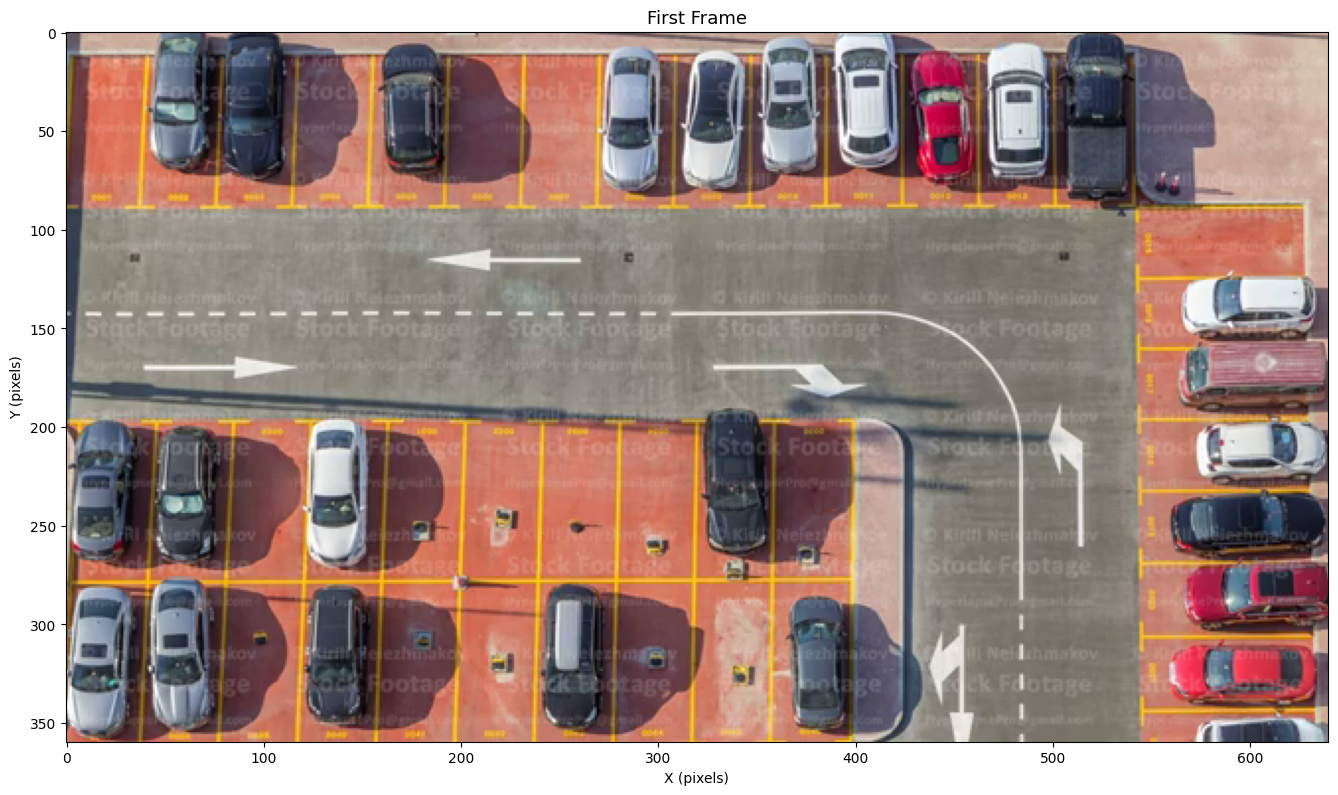

In [4]:
# visualize first frame of our video to see layout. 
first_frame = get_first_frame(VIDEO_PATH)

plt.figure(figsize=(14, 8))
plt.imshow(first_frame)
plt.title("First Frame", fontsize=13)
plt.axis("on")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.tight_layout()
plt.show()

In [5]:
# open our json values from draw_spots 
with open("ParkingSpots.json") as f:
    parking_spots = [np.array(s, np.int32) for s in json.load(f)]

print(f"found {len(parking_spots)} parking spots ")

found 41 parking spots 


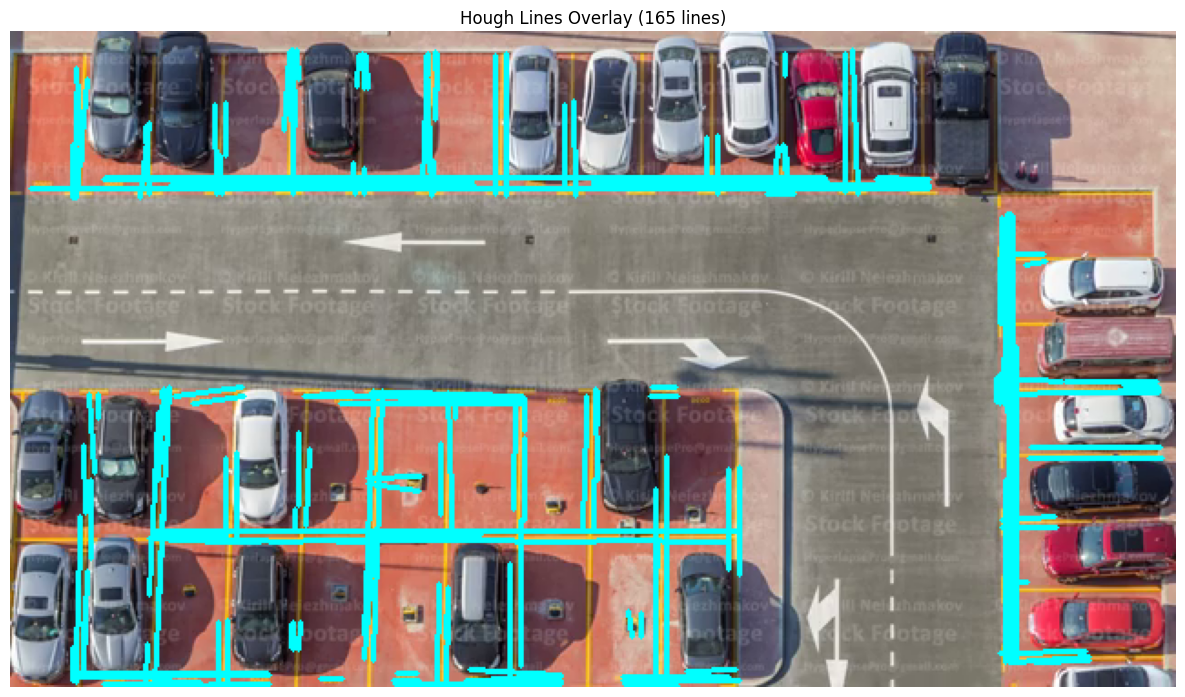

In [6]:
# optional hough line visualization, another way to get spots using hough line but a little finicky
hough_vis = first_frame.copy()

hsv = cv2.cvtColor(first_frame, cv2.COLOR_RGB2HSV)
lower_yellow = np.array([12, 65, 65], dtype=np.uint8)   
upper_yellow = np.array([45, 255, 255], dtype=np.uint8)  # look for yellow due to parking spaces being yellow 
yellow_mask = cv2.inRange(hsv, lower_yellow, upper_yellow)

# keep search inside parking polygons to reduce unrelated lines
spot_mask = np.zeros_like(yellow_mask, dtype=np.uint8)
for poly in parking_spots:
    pts = np.array(poly, np.int32).reshape((-1, 1, 2))
    cv2.fillPoly(spot_mask, [pts], 255)

search_mask = cv2.bitwise_and(yellow_mask, spot_mask)

# clean mask a bit to connect dashed/weak paint
kernel = np.ones((3, 3), np.uint8)
search_mask = cv2.morphologyEx(search_mask, cv2.MORPH_OPEN, kernel, iterations=1)
search_mask = cv2.morphologyEx(search_mask, cv2.MORPH_DILATE, kernel, iterations=1)

edges = cv2.Canny(search_mask, 25, 100)

lines = cv2.HoughLinesP( #adjust these parameters 
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=14,
    minLineLength=10,
    maxLineGap=24,
)

line_count = 0
if lines is not None:
    for l in lines[:700]:
        x1, y1, x2, y2 = l[0]
        if np.hypot(x2 - x1, y2 - y1) < 8:
            continue
        cv2.line(hough_vis, (x1, y1), (x2, y2), (0, 255, 255), 2)
        line_count += 1

plt.figure(figsize=(12, 7))
plt.imshow(hough_vis)
plt.title(f"Hough Lines Overlay ({line_count} lines)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
# draw our parking spot polygons from json 
def draw_rois(frame_rgb, spots, color=(0, 200, 255)):
    vis = frame_rgb.copy()
    for i, poly in enumerate(spots): 
        pts = np.array(poly, np.int32).reshape((-1, 1, 2)) # reshape our points because cv2 expecting 
        cv2.polylines(vis, [pts], True, color, 2)
        cx = int(np.mean([p[0] for p in poly]))
        cy = int(np.mean([p[1] for p in poly]))
        cv2.putText(vis, str(i + 1), (cx - 8, cy + 6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return vis

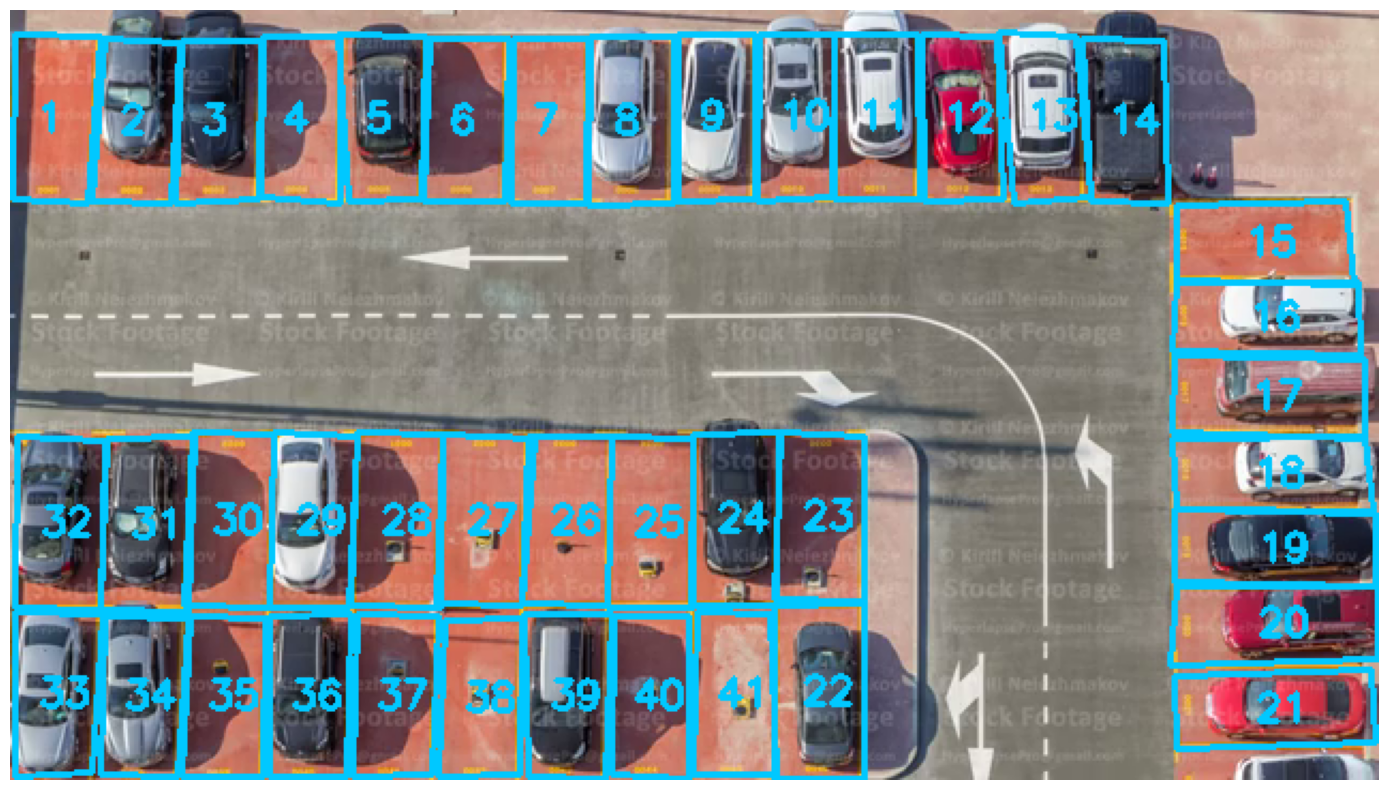

In [8]:
# visualize our spots 
roi_preview = draw_rois(first_frame, parking_spots) # use first frame and apply mask over it with spots 
plt.figure(figsize=(14, 8))
plt.imshow(roi_preview)
plt.axis("off")
plt.tight_layout()
plt.show()

In [9]:
def classify_spot(gray_frame, poly, threshold=LAPLACIAN_THRESHOLD):
    pts = np.array(poly, np.int32).reshape((-1, 1, 2))
    x, y, w, h = cv2.boundingRect(pts)

    roi = gray_frame[y:y + h, x:x + w]
    if roi.size == 0:
        return False, 0.0

    local_pts = pts - np.array([[[x, y]]], dtype=np.int32)
    poly_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(poly_mask, [local_pts], 255)

    if cv2.countNonZero(poly_mask) == 0:
        return False, 0.0

    laplacian = cv2.Laplacian(roi, cv2.CV_64F)
    score = float(laplacian[poly_mask > 0].var())
    return score > threshold, round(score, 2)

In [10]:
def check_motion_in_spot(fg_mask, poly, threshold=MOTION_PIXEL_THRESHOLD):
    pts = np.array(poly, np.int32).reshape((-1, 1, 2))
    x, y, w, h = cv2.boundingRect(pts)

    roi_mask = fg_mask[y:y + h, x:x + w]
    if roi_mask.size == 0:
        return False, 0

    local_pts = pts - np.array([[[x, y]]], dtype=np.int32)
    poly_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(poly_mask, [local_pts], 255)

    active_pixels = cv2.bitwise_and(roi_mask, roi_mask, mask=poly_mask)
    count = cv2.countNonZero(active_pixels)
    return count > threshold, count

In [11]:
def annotate_frame(frame, spots, occupancy, motion_flags, frame_num, fps):
    vis = frame.copy()
    total = len(spots)
    occupied_count = sum(occupancy)
    free_count = total - occupied_count

    for i, poly in enumerate(spots):
        occ = occupancy[i]
        mot = motion_flags[i]

        if mot:
            color = (0, 215, 255)   # Yellow - motion
            label = f"S{i+1} MOV"
        elif occ:
            color = (0, 0, 220)     # Red - occupied (BGR)
            label = f"S{i+1} OCC"
        else:
            color = (0, 200, 60)    # Green - free
            label = f"S{i+1} FREE"

        pts = np.array(poly, np.int32).reshape((-1, 1, 2))
        cv2.polylines(vis, [pts], True, color, 2)

        cx = int(np.mean(pts[:, 0, 0]))
        cy = int(np.mean(pts[:, 0, 1]))
        cv2.putText(vis, label, (cx - 20, cy + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    # HUD overlay
    hud_h = 70
    overlay = vis.copy()
    cv2.rectangle(overlay, (0, 0), (vis.shape[1], hud_h), (20, 20, 20), -1)
    cv2.addWeighted(overlay, 0.6, vis, 0.4, 0, vis)

    timestamp = f"Frame {frame_num} | {frame_num / fps:.1f}s"
    cv2.putText(vis, timestamp, (10, 22),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
    cv2.putText(vis, f"FREE: {free_count}", (10, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 200, 60), 2)
    cv2.putText(vis, f"OCCUPIED: {occupied_count}", (130, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 220), 2)
    cv2.putText(vis, f"TOTAL: {total}", (340, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (200, 200, 200), 2)

    motion_any = any(motion_flags)
    if motion_any:
        cv2.putText(vis, "MOTION DETECTED", (vis.shape[1] - 240, 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 215, 255), 2)

    return vis

In [12]:
occupancy_over_time = []   # list of (frame_num, free_count, occ_count)
motion_events = []         # list of (frame_num, timestamp_s, spot_indices)

# open our video 
cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
output_fps = max(1, fps * 0.5) # 0.5 = half speed, 0.25 = quarter speed, adjust these to slow down or speed up the notebook output 
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, output_fps, (frame_w, frame_h))

# apply our MOG2 and assing history and threshold from parameters above to check for cars 
fgbg = cv2.createBackgroundSubtractorMOG2(
    history=MOG2_HISTORY,
    varThreshold=MOG2_VAR_THRESHOLD,
    detectShadows=True
)

# progress widget 
progress = widgets.IntProgress(
    value=0, min=0, max=total_frames,
    description="Processing:", bar_style="info", layout=widgets.Layout(width="80%")
)
status_label = widgets.Label(value="Starting...")
display(widgets.VBox([progress, status_label]))

preview_out = widgets.Output()
display(preview_out)

# main loop 
frame_num = 0
start_time = time.time()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) # apply gray scaling and blur to help MOG2
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    fg_mask = fgbg.apply(frame)

    # remove shadows (value 127) - keep only full foreground (255)
    _, fg_mask = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)

    # morphological cleanup on mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_DILATE, kernel)

    # classify each polygon spot
    occupancy = []
    motion_flags = []

    for spot in parking_spots: 
        occ, score = classify_spot(gray, spot)
        mot, px = check_motion_in_spot(fg_mask, spot)
        occupancy.append(occ)
        motion_flags.append(mot)

    # log stats
    occ_count = sum(occupancy)
    free_count = len(parking_spots) - occ_count
    occupancy_over_time.append((frame_num, free_count, occ_count))

    # log motion events
    spots_with_motion = [i for i, m in enumerate(motion_flags) if m]
    if spots_with_motion:
        motion_events.append({
            "frame": frame_num,
            "time_s": round(frame_num / fps, 2),
            "spots": [s + 1 for s in spots_with_motion]
        })

    # annotate and write
    annotated = annotate_frame(frame, parking_spots, occupancy, motion_flags, frame_num, fps)
    out.write(annotated)

    # notebook preview every N frames
    if frame_num % PREVIEW_EVERY_N_FRAMES == 0:
        rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        _, buf = cv2.imencode(".jpg", cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_JPEG_QUALITY, 70])
        with preview_out:
            clear_output(wait=True)
            display(IPImage(data=buf.tobytes()))

        elapsed = time.time() - start_time
        eta = (elapsed / max(frame_num, 1)) * (total_frames - frame_num)
        status_label.value = f"Frame {frame_num}/{total_frames} | Free: {free_count} | Occupied: {occ_count} | ETA: {eta:.0f}s"

    progress.value = frame_num
    frame_num += 1

cap.release()
out.release()

elapsed_total = time.time() - start_time
status_label.value = f"Done! Processed {frame_num} frames in {elapsed_total:.1f}s"
progress.bar_style = "success"
print(f"\nOutput saved to: {OUTPUT_PATH}")
print(f"Total motion events logged: {len(motion_events)}")

Output()


Output saved to: ParkingOutput.mp4
Total motion events logged: 172


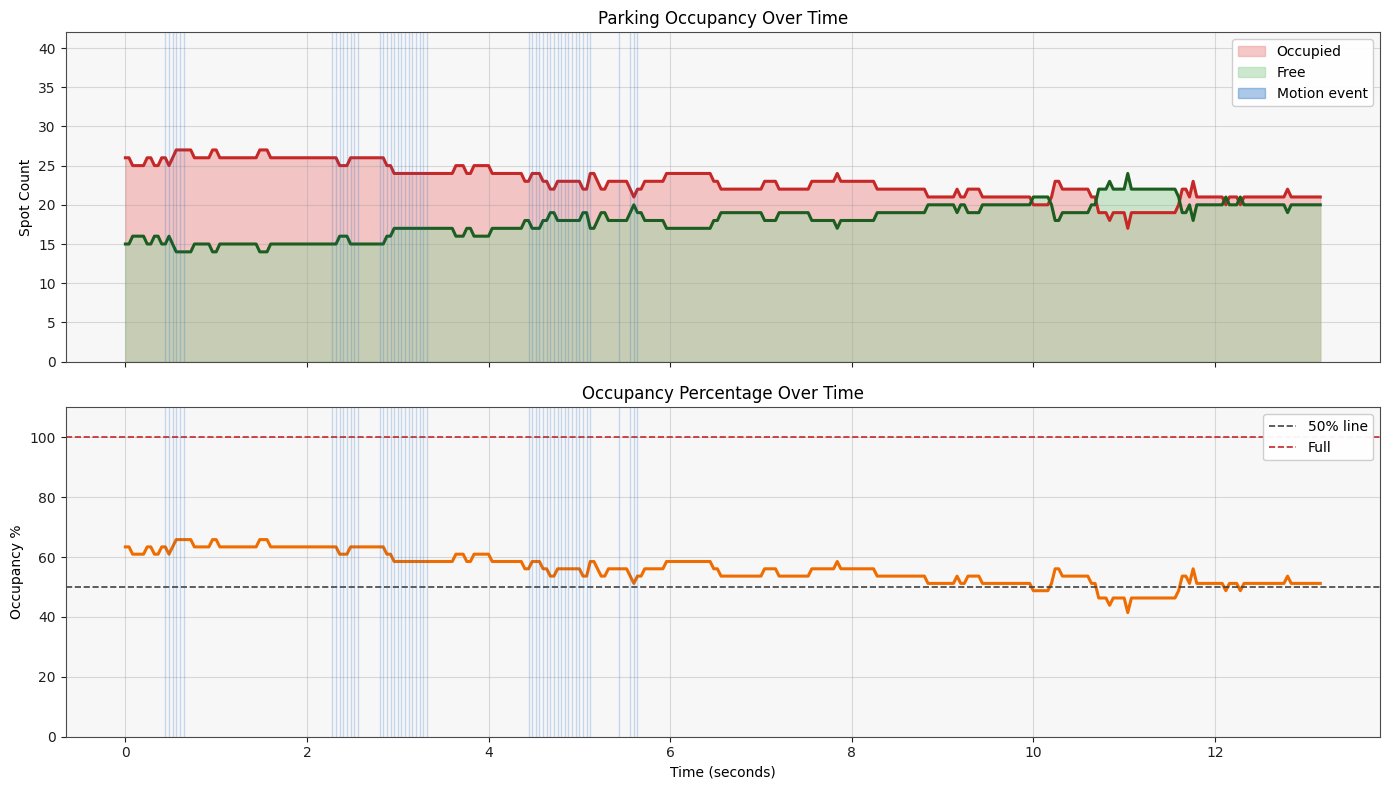

In [13]:
if occupancy_over_time:
    frames_arr = np.array([r[0] for r in occupancy_over_time])
    time_arr   = frames_arr / fps
    free_arr   = np.array([r[1] for r in occupancy_over_time])
    occ_arr    = np.array([r[2] for r in occupancy_over_time])

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.patch.set_facecolor("white")

    # Higher-contrast palette for light backgrounds
    occ_fill = "#ef9a9a"
    free_fill = "#a5d6a7"
    occ_line = "#c62828"
    free_line = "#1b5e20"
    pct_line = "#ef6c00"
    motion_color = "#1565c0"

    for ax in axes:
        ax.set_facecolor("#f7f7f7")
        ax.tick_params(colors="#1f1f1f")
        for spine in ax.spines.values():
            spine.set_color("#4a4a4a")
        ax.grid(True, color="#9e9e9e", alpha=0.35, linewidth=0.8)

    # Occupancy over time
    axes[0].fill_between(time_arr, occ_arr, alpha=0.55, color=occ_fill, label="Occupied")
    axes[0].fill_between(time_arr, free_arr, alpha=0.55, color=free_fill, label="Free")
    axes[0].plot(time_arr, occ_arr, color=occ_line, linewidth=2.2)
    axes[0].plot(time_arr, free_arr, color=free_line, linewidth=2.2)
    axes[0].set_ylabel("Spot Count")
    axes[0].set_title("Parking Occupancy Over Time")
    axes[0].set_ylim(0, len(parking_spots) + 1)

    # Occupancy % over time
    occ_pct = (occ_arr / len(parking_spots)) * 100
    axes[1].plot(time_arr, occ_pct, color=pct_line, linewidth=2.2)
    axes[1].axhline(50, color="#424242", linestyle="--", linewidth=1.2, label="50% line")
    axes[1].axhline(100, color=occ_line, linestyle="--", linewidth=1.2, label="Full")
    axes[1].set_ylabel("Occupancy %")
    axes[1].set_xlabel("Time (seconds)")
    axes[1].set_title("Occupancy Percentage Over Time")
    axes[1].set_ylim(0, 110)

    # Mark motion events on both plots
    for event in motion_events[:50]:  # limit markers for readability
        for ax in axes:
            ax.axvline(event["time_s"], color=motion_color, alpha=0.22, linewidth=1.0)

    motion_patch = mpatches.Patch(color=motion_color, alpha=0.35, label="Motion event")
    top_handles, top_labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles=top_handles + [motion_patch], loc="upper right", framealpha=0.95)
    axes[1].legend(loc="upper right", framealpha=0.95)

    plt.tight_layout()
    plt.show()

In [14]:
print(f"Total motion events detected: {len(motion_events)}\n")

if motion_events:
    print(f'{"Time (s)":>10}  {"Frame":>8}  Spots Triggered')
    print("-" * 40)
    # Print up to 50 events
    for event in motion_events[:50]:
        spots_str = ", ".join(f"Spot {s}" for s in event["spots"])
        print(f'{event["time_s"]:>10.2f}  {event["frame"]:>8}  {spots_str}')
    if len(motion_events) > 50:
        print(f"  ... and {len(motion_events) - 50} more events.")
else:
    print("No motion events detected. Try lowering MOTION_PIXEL_THRESHOLD.")

Total motion events detected: 172

  Time (s)     Frame  Spots Triggered
----------------------------------------
      0.44        11  Spot 27
      0.48        12  Spot 7
      0.52        13  Spot 6, Spot 7, Spot 8
      0.56        14  Spot 6, Spot 7, Spot 8
      0.60        15  Spot 6, Spot 7, Spot 8
      0.64        16  Spot 23
      2.28        57  Spot 9, Spot 10, Spot 11
      2.32        58  Spot 9, Spot 10, Spot 11
      2.36        59  Spot 9, Spot 10, Spot 11
      2.40        60  Spot 9, Spot 10, Spot 11
      2.44        61  Spot 9, Spot 10, Spot 11
      2.48        62  Spot 9, Spot 10, Spot 11
      2.52        63  Spot 9, Spot 10, Spot 11
      2.56        64  Spot 11
      2.80        70  Spot 23
      2.84        71  Spot 23
      2.88        72  Spot 13, Spot 14, Spot 17, Spot 23
      2.92        73  Spot 13, Spot 14, Spot 23, Spot 25, Spot 26
      2.96        74  Spot 13, Spot 14, Spot 23
      3.00        75  Spot 13, Spot 14, Spot 23
      3.04        76  Sp

In [15]:
if occupancy_over_time:
    occ_counts = [r[2] for r in occupancy_over_time]
    free_counts = [r[1] for r in occupancy_over_time]
    total_spots = len(parking_spots)

    print("       PARKING LOT DETECTION SUMMARY")
    print(f"  Video duration     : {total_frames / fps:.1f}s ({total_frames} frames)")
    print(f"  Total spots        : {total_spots}")
    print(f"  Avg occupied       : {np.mean(occ_counts):.1f} ({np.mean(occ_counts)/total_spots*100:.1f}%)")
    print(f"  Avg free           : {np.mean(free_counts):.1f} ({np.mean(free_counts)/total_spots*100:.1f}%)")
    print(f"  Peak occupancy     : {max(occ_counts)} spots ({max(occ_counts)/total_spots*100:.0f}%)")
    print(f"  Min occupancy      : {min(occ_counts)} spots")
    print(f"  Total motion events: {len(motion_events)}")
    print(f"  Output video       : {OUTPUT_PATH}")
 

       PARKING LOT DETECTION SUMMARY
  Video duration     : 13.2s (330 frames)
  Total spots        : 41
  Avg occupied       : 23.0 (56.0%)
  Avg free           : 18.0 (44.0%)
  Peak occupancy     : 27 spots (66%)
  Min occupancy      : 17 spots
  Total motion events: 172
  Output video       : ParkingOutput.mp4
